# **Pertpy-GPU**

**Accelerated Perturbation Analysis**

**Authors:** [Lukas Heumos](https://github.com/zethson), [Severin Dicks](https://github.com/Intron7)
**Copyright** [scverse](https://scverse.org)

Here, we explore GPU-accelerated perturbation analysis using **rapids-singlecell**'s `rsc.ptg` module, which mirrors the API of [pertpy](https://pertpy.readthedocs.io).

The first part quantifies how strongly each perturbation shifts the cell-state distribution relative to controls with the **E-distance** (energy distance) via the `Distance` class.
The second part measures *guide efficacy* — which cells were actually perturbed — with GPU `Mixscape` and `Mixscale`.

By running these analyses on GPUs, we can scale to large perturbation screens (many groups, many cells) where they would otherwise be a bottleneck.

In [1]:
import rapids_singlecell as rsc
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Example Data

We use the `distance_example` dataset of pertpy — a small, preprocessed subset of the Perturb-seq data from [Dixit et al., 2016](https://doi.org/10.1016/j.cell.2016.11.038) — which contains a `perturbation` annotation in `.obs` and a PCA embedding in `.obsm["X_pca"]`.

In [2]:
adata = pt.dt.distance_example()
adata

Output()

AnnData object with n_obs × n_vars = 3200 × 2000
    obs: 'perturbation', 'grna_lenient', 'target', 'moi', 'cell_line', 'celltype', 'perturbation_type', 'cancer', 'disease', 'guide_id', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'n_counts'
    var: 'gene_id', 'mt', 'ribo', 'ncounts', 'ncells', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

## Prepare for distance metrics

Distance metrics are computed in PCA space to avoid the curse of dimensionality.

In [3]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.pca(adata, n_comps=50)

## Pairwise E-distances

The `Distance` class computes pairwise distances between all groups defined by a column in `.obs`.
By default it reads the embedding from `.obsm["X_pca"]`.

In [4]:
%%time
distance = rsc.ptg.Distance(metric="edistance", obsm_key="X_pca")
df = distance.pairwise(adata, groupby="perturbation")
df.head()

CPU times: user 89.6 ms, sys: 110 ms, total: 200 ms
Wall time: 211 ms


perturbation,control,p-INTERGENIC216151,p-INTERGENIC393453,p-INTERGENIC393453_p-sgELF1-2,p-INTERGENIC1144056,p-INTERGENIC1216445,p-sgCREB1-2,p-sgCREB1-4,p-sgCREB1-5,p-sgE2F4-6,...,p-sgETS1-5,p-sgGABPA-1,p-sgGABPA-9,p-sgIRF1-2,p-sgIRF1-3,p-sgNR2C2-2,p-sgNR2C2-3,p-sgNR2C2-5,p-sgYY1-3,p-sgYY1-10
perturbation,,,,,,,,,,,,,,,,,,,,,
control,0.000000,0.186349,0.221330,0.271879,0.262409,0.259742,0.252047,0.388347,0.255591,0.305327,...,11.117791,11.345466,10.817897,10.989600,10.938346,10.762515,10.968606,11.135169,10.956794,11.002570
p-INTERGENIC216151,0.186349,0.000000,-0.004431,0.029948,-0.004577,-0.007887,0.033902,0.007109,-0.023689,-0.010981,...,10.886154,11.144892,10.528141,10.766275,10.794704,10.597767,10.688717,10.957037,10.697678,10.740093
p-INTERGENIC393453,0.221330,-0.004431,0.000000,-0.011825,0.014310,0.090172,0.001601,0.047546,0.031595,-0.002493,...,10.911251,11.148907,10.549555,10.722811,10.763330,10.516941,10.690413,10.937794,10.667976,10.665668
p-INTERGENIC393453_p-sgELF1-2,0.271879,0.029948,-0.011825,0.000000,0.037039,0.076024,0.072380,0.057895,0.060161,-0.025310,...,10.918887,11.118718,10.542024,10.687474,10.792460,10.574533,10.676623,10.971745,10.721988,10.744924
p-INTERGENIC1144056,0.262409,-0.004577,0.014310,0.037039,0.000000,0.050689,0.090553,0.043809,0.030746,-0.004828,...,10.845416,11.141154,10.521079,10.756492,10.758622,10.565118,10.643743,10.930161,10.650748,10.681153


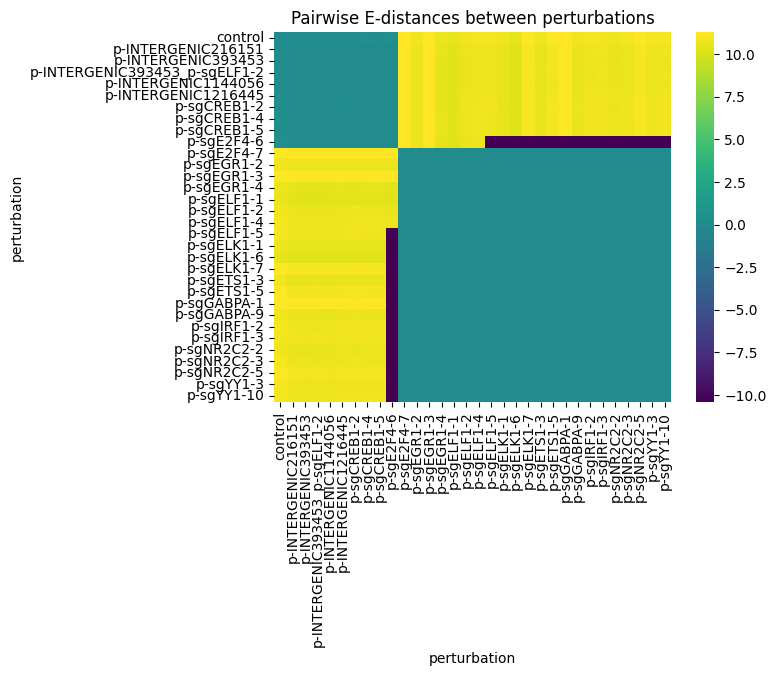

In [5]:
sns.heatmap(df, robust=True, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Pairwise E-distances between perturbations")
plt.show()

## Contrast Against a Baseline

A common perturbation-screen question is *"how strongly does each perturbation shift cells away from the unperturbed baseline?"*.
We answer this with `Distance.create_contrasts` (which builds a tidy contrasts table — one row per `(target, reference)` pair) and `Distance.contrast_distances` (which fills in the distance for each contrast).
This is more flexible than the raw pairwise matrix: you can pass multiple references, restrict to a subset of targets, or stratify by another `.obs` column (e.g. cell type) via `split_by`.

In [6]:
%%time
contrasts = rsc.ptg.Distance.create_contrasts(
    adata, groupby="perturbation", selected_group="control"
)
result = distance.contrast_distances(adata, contrasts=contrasts)
result.sort_values("edistance", ascending=False).head(10)

CPU times: user 4.23 ms, sys: 1.02 ms, total: 5.25 ms
Wall time: 5.15 ms


,perturbation,reference,edistance
6,p-sgCREB1-4,control,0.388347
8,p-sgE2F4-6,control,0.305327
14,p-sgELF1-2,control,0.284898
4,p-INTERGENIC393453_p-sgELF1-2,control,0.271879
0,p-INTERGENIC1144056,control,0.262409
1,p-INTERGENIC1216445,control,0.259742
13,p-sgELF1-1,control,0.256044
7,p-sgCREB1-5,control,0.255591
5,p-sgCREB1-2,control,0.252047
12,p-sgEGR1-4,control,0.231539


## Bootstrap Variance Estimation

Setting `bootstrap=True` returns both the distance estimates and a per-pair variance, computed by resampling cells.
Unlike pertpy's CPU implementation, the GPU version recomputes distances each iteration rather than precomputing an n×n cell-distance matrix, so memory scales linearly in the number of cells.

In [7]:
%%time
df_mean, df_var = distance.pairwise(
    adata, groupby="perturbation", bootstrap=True, n_bootstrap=50, random_state=0
)
df_var.head()

CPU times: user 170 ms, sys: 25 ms, total: 195 ms
Wall time: 206 ms


perturbation,control,p-INTERGENIC216151,p-INTERGENIC393453,p-INTERGENIC393453_p-sgELF1-2,p-INTERGENIC1144056,p-INTERGENIC1216445,p-sgCREB1-2,p-sgCREB1-4,p-sgCREB1-5,p-sgE2F4-6,...,p-sgETS1-5,p-sgGABPA-1,p-sgGABPA-9,p-sgIRF1-2,p-sgIRF1-3,p-sgNR2C2-2,p-sgNR2C2-3,p-sgNR2C2-5,p-sgYY1-3,p-sgYY1-10
perturbation,,,,,,,,,,,,,,,,,,,,,
control,0.000000,0.615649,0.676249,0.707373,0.690252,0.755485,0.730110,0.638012,0.613149,0.629978,...,0.492959,0.507649,0.545650,0.510374,0.527145,0.538763,0.512156,0.527787,0.539033,0.561692
p-INTERGENIC216151,0.615649,0.000000,0.620489,0.845120,0.677615,0.606445,0.695761,0.449387,0.503358,0.487890,...,0.372298,0.412535,0.424213,0.457977,0.380719,0.561015,0.367474,0.583240,0.481967,0.469870
p-INTERGENIC393453,0.676249,0.620489,0.000000,0.729668,0.739731,0.572042,0.667218,0.475155,0.465108,0.439002,...,0.378681,0.478792,0.450716,0.400178,0.476515,0.455280,0.392606,0.477263,0.418816,0.487898
p-INTERGENIC393453_p-sgELF1-2,0.707373,0.845120,0.729668,0.000000,0.940516,0.728478,0.796337,0.615656,0.631690,0.575077,...,0.507100,0.495823,0.604121,0.634320,0.585329,0.621915,0.548688,0.698824,0.528947,0.545237
p-INTERGENIC1144056,0.690252,0.677615,0.739731,0.940516,0.000000,0.739008,0.698735,0.606369,0.644801,0.539034,...,0.463750,0.559079,0.561818,0.606893,0.667035,0.612540,0.575786,0.593550,0.513973,0.595869


# Perturbation efficacy: Mixscape & Mixscale

In a pooled CRISPR screen, not every cell that received a guide RNA is actually perturbed.
Incomplete knockout and cells that escape perturbation dilute the signal, so before any downstream analysis we want to know *how well each guide worked*.

Two complementary GPU-accelerated tools in `rsc.ptg` answer this, mirroring the API of [pertpy](https://pertpy.readthedocs.io)'s `Mixscape` and `Mixscale`:

- **`Mixscape`** classifies each cell as *knocked out* (KO) or *non-perturbed* (NP) with a per-target-gene Gaussian mixture on the perturbation signature.
- **`Mixscale`** assigns each cell a *continuous* perturbation-efficiency score instead of a binary call.

We follow pertpy's [perturbation efficacy tutorial](https://pertpy.readthedocs.io/en/latest/tutorials/notebooks/perturbation_efficacy.html) on the Papalexi 2021 ECCITE-seq dataset: THP-1 cells with a CRISPR screen targeting regulators of the interferon-γ response, across three replicates.

## Load the ECCITE-seq data

`pertpy` ships the Papalexi 2021 screen as a `MuData` object.
We work with the RNA modality and attach the shared perturbation annotations (`gene_target`, `replicate`, cell-cycle `phase`) that the analysis needs.

In [8]:
mdata = pt.dt.papalexi_2021()
rna = mdata["rna"].copy()
rna.obs[["gene_target", "perturbation", "replicate", "phase"]] = mdata.obs.loc[
    rna.obs_names, ["gene_target", "perturbation", "replicate", "phase"]
]
rna

/home/lheumos/miniforge3/envs/rsc/lib/python3.13/site-packages/mudata/_core/mudata.py:1467: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'gene_target', 'perturbation', 'replicate', 'phase'
    var: 'name'

## Preprocess on the GPU

We move the data to the GPU and run a standard normalize → log1p → highly-variable-genes → PCA → neighbors → UMAP pipeline, entirely with `rsc`.

In [9]:
rsc.get.anndata_to_GPU(rna)
rsc.pp.normalize_total(rna, target_sum=1e4)
rsc.pp.log1p(rna)
rsc.pp.highly_variable_genes(rna, n_top_genes=2000)
rna = rna[:, rna.var["highly_variable"]].copy()
rsc.pp.pca(rna, n_comps=50)
rsc.pp.neighbors(rna, n_neighbors=15, metric="cosine")
rsc.tl.umap(rna)
rna.obsm["X_umap_raw"] = rna.obsm["X_umap"].copy()
rna

AnnData object with n_obs × n_vars = 20729 × 2000
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'gene_target', 'perturbation', 'replicate', 'phase'
    var: 'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_raw'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## The perturbation signal is buried under confounders

On the raw-expression UMAP, cells cluster by technical replicate and cell-cycle phase rather than by the targeted gene.
This confounding is exactly what makes calling perturbation efficacy hard.

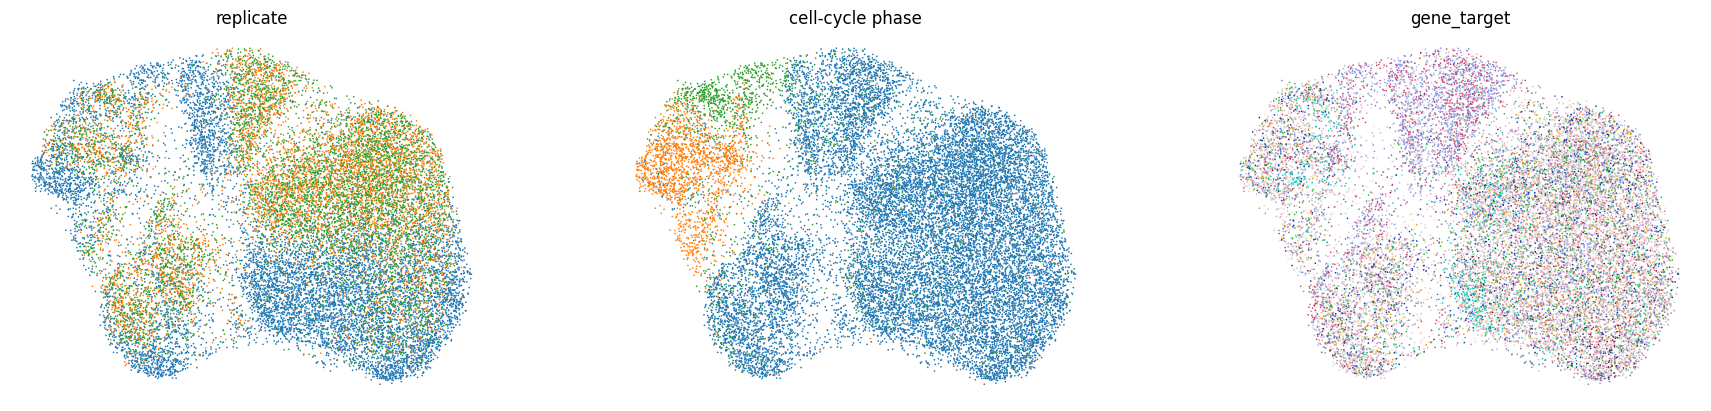

In [10]:
sc.pl.embedding(
    rna,
    "X_umap_raw",
    color=["replicate", "phase", "gene_target"],
    title=["replicate", "cell-cycle phase", "gene_target"],
    legend_loc="none",
    frameon=False,
    ncols=3,
)

## Compute the perturbation signature

`perturbation_signature` replaces each cell's expression with the residual against its nearest control (`NT`) neighbors, computed separately per `replicate`.
This removes confounding variation, leaving what is attributable to the perturbation, and writes the result to `.layers["X_pert"]`.
Re-embedding on the signature exposes perturbation-driven structure that was previously hidden.

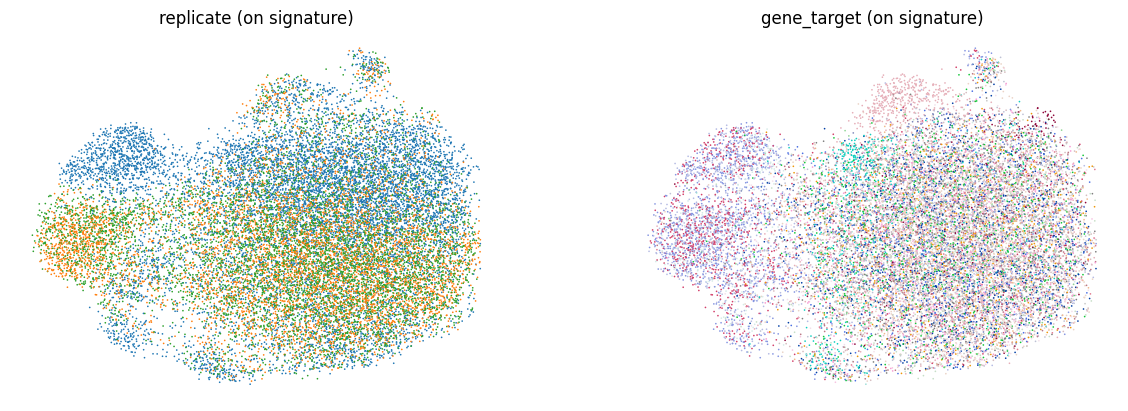

In [11]:
ms = rsc.ptg.Mixscape()
ms.perturbation_signature(
    rna, pert_key="gene_target", control="NT", split_by="replicate"
)

rsc.pp.pca(rna, n_comps=50, layer="X_pert")
rsc.pp.neighbors(rna, n_neighbors=15, metric="cosine")
rsc.tl.umap(rna)

sc.pl.umap(
    rna,
    color=["replicate", "gene_target"],
    title=["replicate (on signature)", "gene_target (on signature)"],
    legend_loc="none",
    frameon=False,
    ncols=2,
)

## Mixscape: knocked-out vs. non-perturbed

`mixscape` fits, per target gene, a two-component Gaussian mixture (with the control component held fixed) on the perturbation signature and labels each cell knocked out (`KO`) or non-perturbed (`NP`).
Control cells keep the `NT` label.
The global call is written to `.obs["mixscape_class_global"]`.

In [12]:
ms.mixscape(rna, pert_key="gene_target", control="NT")
rna.obs["mixscape_class_global"].value_counts()

mixscape_class_global
NP    13615
KO     4728
NT     2386
Name: count, dtype: int64

... storing 'mixscape_class' as categorical


... storing 'mixscape_class_global' as categorical


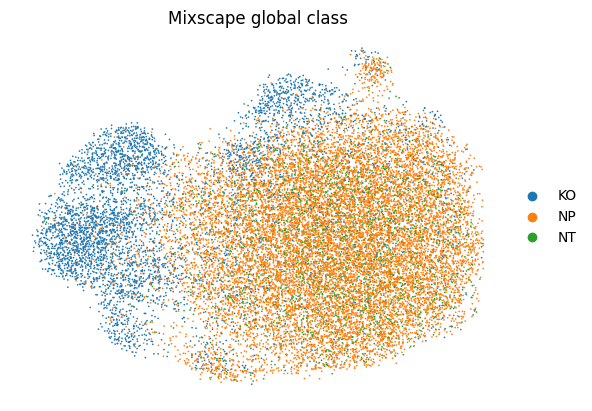

In [13]:
sc.pl.umap(
    rna, color="mixscape_class_global", frameon=False, title="Mixscape global class"
)

## Knockout efficiency per target gene

The fraction of `KO` cells per target gene is a direct, per-guide efficacy readout.
Genes central to the screened pathway are perturbed in most of their cells, while others largely escape.

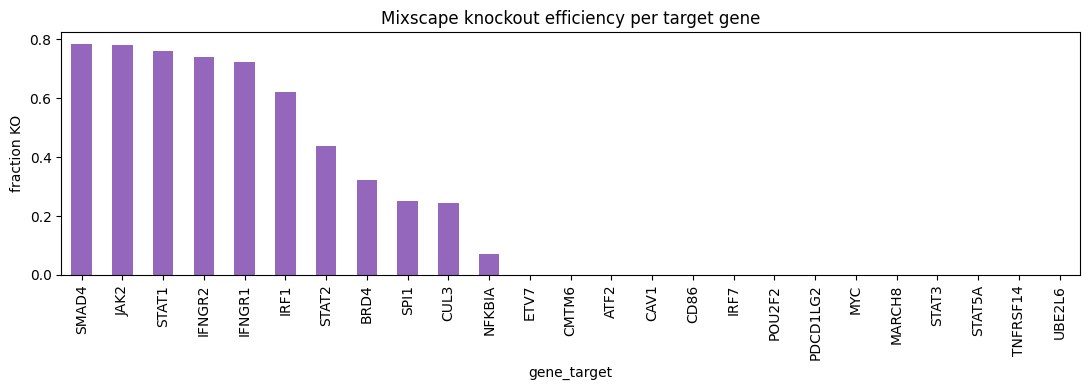

In [14]:
ko = rna.obs.loc[rna.obs["gene_target"] != "NT"].copy()
frac_ko = (
    ko.assign(is_ko=ko["mixscape_class_global"].eq("KO"))
    .groupby("gene_target", observed=True)["is_ko"]
    .mean()
    .sort_values(ascending=False)
)
ax = frac_ko.plot.bar(figsize=(11, 4), color="tab:purple")
ax.set_ylabel("fraction KO")
ax.set_title("Mixscape knockout efficiency per target gene")
plt.tight_layout()
plt.show()

## Visualize perturbations with LDA

`lda` learns a linear-discriminant embedding that maximizes separation between target genes, using the knocked-out and control cells.
Well-separated clusters correspond to perturbations with a distinct transcriptional effect.

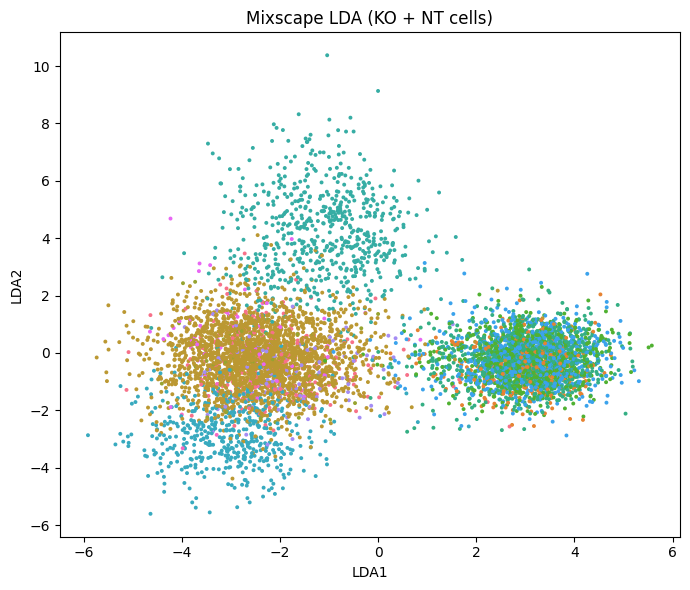

In [15]:
ms.lda(rna, pert_key="gene_target", control="NT")

lda = rna.uns["mixscape_lda"]
subset = rna.obs["mixscape_class_global"].isin(["KO", "NT"]).to_numpy()
lda_df = pd.DataFrame(lda[:, :2], columns=["LDA1", "LDA2"])
lda_df["gene_target"] = rna.obs["gene_target"].to_numpy()[subset]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    lda_df, x="LDA1", y="LDA2", hue="gene_target", s=8, linewidth=0, legend=False
)
plt.title("Mixscape LDA (KO + NT cells)")
plt.tight_layout()
plt.show()

## Mixscale: a continuous efficacy score

Where Mixscape makes a binary call, `Mixscale` projects each cell onto its target's perturbation direction and standardizes it against the controls, giving a *continuous* score.
This resolves a gradient of response strength within a single perturbation, which is useful for CRISPRi/CRISPRa screens.
Control cells score 0.

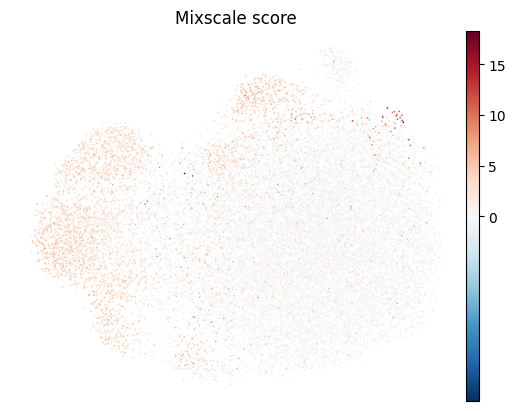

In [16]:
msc = rsc.ptg.Mixscale()
msc.mixscale(rna, pert_key="gene_target", control="NT")
sc.pl.umap(
    rna, color="mixscale_score", frameon=False, cmap="RdBu_r", vcenter=0,
    title="Mixscale score",
)

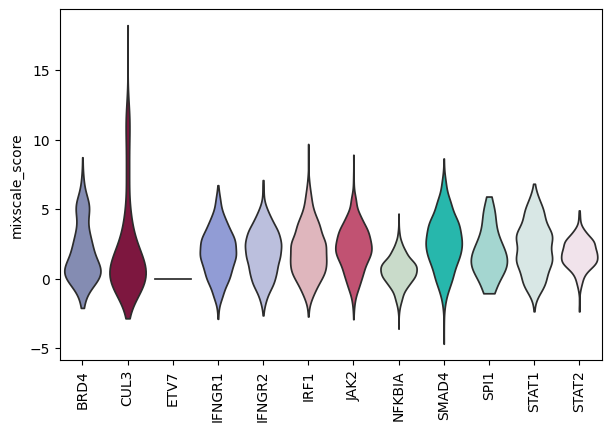

In [17]:
top_targets = frac_ko.head(12).index.tolist()
sc.pl.violin(
    rna[rna.obs["gene_target"].isin(top_targets)].copy(),
    keys="mixscale_score",
    groupby="gene_target",
    rotation=90,
    stripplot=False,
)

## Summary

`rsc.ptg` brings pertpy's perturbation-efficacy workflow to the GPU:

- `perturbation_signature` isolates the perturbation effect from technical confounders.
- `Mixscape` gives a binary knocked-out / non-perturbed call and an LDA visualization.
- `Mixscale` gives a continuous per-cell efficacy score.

Because the signature, differential expression, Gaussian-mixture fitting and scoring all run on the GPU, this scales to the large pooled screens where the CPU implementations become a bottleneck.